In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/online-retail-ii-uci/online_retail_II.csv


<h1>Background</h1>
Nowadays, businesses generate large volumes of data capturing customer behavior. This data provides an important opportunity to understand customers at scale and support personalized services. One of the most widely used applications derived from such data is recommendation systems, which rely on meaningful customer insights to deliver relevant product suggestions.

Before any recommendation can be performed effectively, businesses must first understand who their customers are and how they behave. This foundational step is customer segmentation, and it plays a critical role in personalized recommendations.

For this project, let's use the Online Retail II dataset, which consists of real world e-commerce transactions. The dataset includes invoice, stock code, description, quantity, invoive data, price, customer ID, and country information.

<h2>Main problem</h2>
The main problem addressed in this project is the development of unsupervised customer segments that group similar customers together based on their purchasing behavior.

<h2>Motivation for Choosing This Topic</h2>
Recommendation is one of the most widely used machine learning applications. Recommendation systems power major platforms such as Amazon, Netflix, Spotify, and TikTok.
Segmentation is the foundation of recommendations.

<h2>Project Flow</h2>
This project is structured through Data Loading & Cleaning, Exploratory Data Analysis (EDA), Model Selection and Comparison, Recommendation Exploration, and Results/ Analysis.

Silhouette score is used at the beginning to evaluate the performance, but it cannot work very well, we will go through in detail.

<h1>Data Loading</h1>

In [2]:
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.cluster import KMeans


# Download latest version
path = kagglehub.dataset_download("mashlyn/online-retail-ii-uci")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/online-retail-ii-uci


The dataset includes invoice (object), stock code(object), description(object), quantity(int), invoive data(object), price(float), customer ID(float), and country information(object).

In [3]:
data = pd.read_csv("/kaggle/input/online-retail-ii-uci/online_retail_II.csv")

df = data.copy()

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


Totally 8 features and 1067371 data points.

In [5]:
print(df.shape)

(1067371, 8)


<h1>EDA</h1>

Exploratory Data Analysis (EDA) is the process of exploring, summarizing, and visualizing a dataset before building any model.

<h2>Data Cleaning</h2>

First, let's check clearn the dataset: 

4382 missing description, and 243007 missing customer ID. Since customer ID is important for customer segmentation, I will remove those data points.

In [6]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [7]:
# Drop rows without customer ID
df = df.dropna(subset=["Customer ID"])

# Remove negative or zero quantities
df = df[df["Quantity"] > 0]

# Remove negative prices
df = df[df["Price"] > 0]

# Remove duplicates
df = df.drop_duplicates()

# Convert Customer ID to integer
df["Customer ID"] = df["Customer ID"].astype(int)

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print(df.shape)


(779425, 8)


In [8]:
#Re-check if there is still null item
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [9]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


In [10]:
print("Unique customers:", df["Customer ID"].nunique())
print("Unique products:", df["StockCode"].nunique())
print("Countries:", df["Country"].nunique())
df["Country"].value_counts().head()

Unique customers: 5878
Unique products: 4631
Countries: 41


Country
United Kingdom    700388
Germany            16432
EIRE               15565
France             13511
Netherlands         5085
Name: count, dtype: int64

In [11]:
df["TotalAmount"] = df["Quantity"] * df["Price"]
df["TotalAmount"].describe()

count    779425.000000
mean         22.291823
std         227.427075
min           0.001000
25%           4.950000
50%          12.480000
75%          19.800000
max      168469.600000
Name: TotalAmount, dtype: float64

It is clearly the max amount is too big compares with the mean, 25%, 50% and 75%. So we need to scale it.

Otherwise, the diagram is extremely skewed.

This is the histogram of spending (TotalAmount), but clearly it is not a good distribution.
Most items are between 1-20, but a few reach hundreds or thousands.

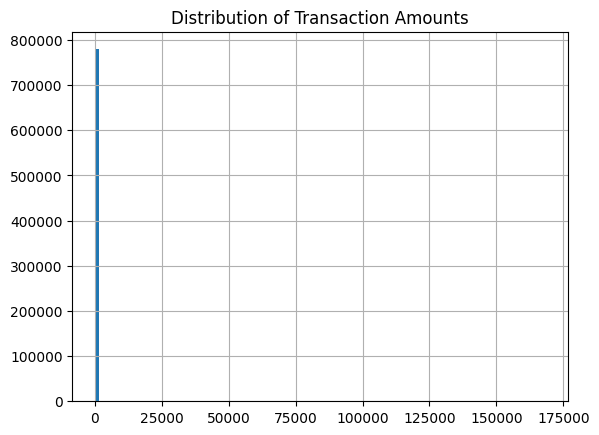

In [12]:
df["TotalAmount"].hist(bins=100)
plt.title("Distribution of Transaction Amounts")
plt.show()

So let us take the log scales down large numbers way more strongly than small numbers.

But the data includes extremly small values close to 0, so we use log(1+x).

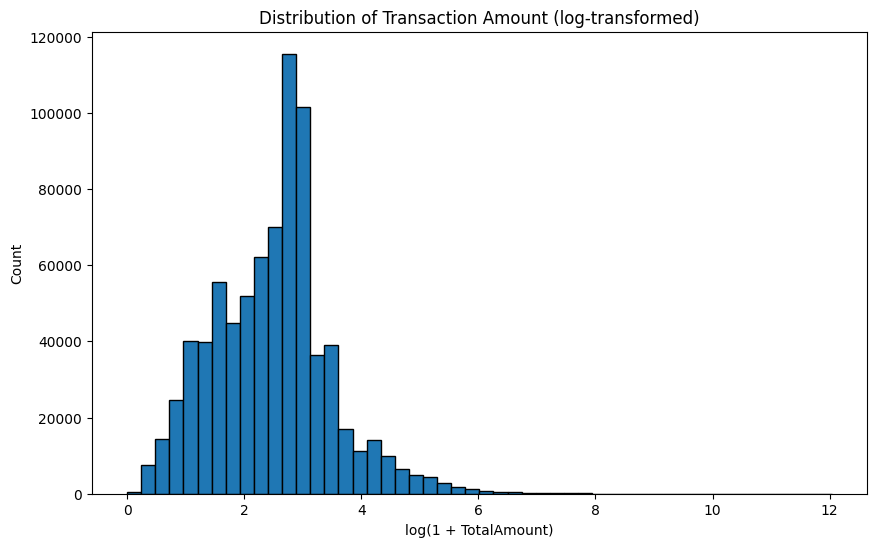

In [13]:
plt.figure(figsize=(10,6))
plt.hist(np.log1p(df['TotalAmount']), bins=50, edgecolor='black')
plt.title("Distribution of Transaction Amount (log-transformed)")
plt.xlabel("log(1 + TotalAmount)")
plt.ylabel("Count")
plt.show()

Check the most expensive and least expensive items.

The most expensive item is paper craft, whose unit price is only 2.08, but the quantity is 80995. It is probably a business bulk purchase.

In [14]:
max_row = df.loc[df['TotalAmount'].idxmax()]
min_row = df.loc[df['TotalAmount'].idxmin()]

print("Most Expensive Transaction:")
print("Invoice:", max_row["Invoice"])
print("Description:", max_row["Description"])
print("StockCode:", max_row["StockCode"])
print("Quantity:", max_row["Quantity"])
print("Price per unit:", max_row["Price"])
print("Customer ID:", max_row["Customer ID"])
print("Total Amount:", max_row["TotalAmount"])
print("Country:", max_row["Country"])

print("================================")

print("Least Expensive Transaction:")
print("Invoice:", min_row["Invoice"])
print("Description:", min_row["Description"])
print("StockCode:", min_row["StockCode"])
print("Quantity:",min_row["Quantity"])
print("Price per unit:", min_row["Price"])
print("Customer ID:", min_row["Customer ID"])
print("Total Amount:", min_row["TotalAmount"])
print("Country:", min_row["Country"])

Most Expensive Transaction:
Invoice: 581483
Description: PAPER CRAFT , LITTLE BIRDIE
StockCode: 23843
Quantity: 80995
Price per unit: 2.08
Customer ID: 16446
Total Amount: 168469.6
Country: United Kingdom
Least Expensive Transaction:
Invoice: 494914
Description: PADS TO MATCH ALL CUSHIONS
StockCode: PADS
Quantity: 1
Price per unit: 0.001
Customer ID: 16705
Total Amount: 0.001
Country: United Kingdom


Quantity is also distributed from many small purchases (1–3 items) and huge purchases (10000+).

The top items are outliers. I ran a separate analysis in another notebook to compare.

In [15]:
df.nlargest(10, 'TotalAmount')[['Invoice','Description','Quantity','Price', 'Customer ID','TotalAmount']]

,Invoice,Description,Quantity,Price,Customer ID,TotalAmount
1065882,581483,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446,168469.60
587080,541431,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346,77183.60
748132,556444,PICNIC BASKET WICKER 60 PIECES,60,649.50,15098,38970.00
432176,530715,ROTATING SILVER ANGELS T-LIGHT HLDR,9360,1.69,15838,15818.40
135013,502263,Manual,1,10953.50,12918,10953.50
358639,524159,Manual,1,10468.80,14063,10468.80
74356,496115,Manual,1,8985.60,17949,8985.60
228042,511465,PINK PAPER PARASOL,3500,2.55,18008,8925.00
698843,551697,POSTAGE,1,8142.75,16029,8142.75
873786,567423,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,17450,7144.72


To better understand product-level trends, we aggregated total quantity sold per product description. Then we examined the customer distribution for the Top 10 products. Widely purchased items are suitable for global recommendations, while niche items may be more effective in personalized recommendations.

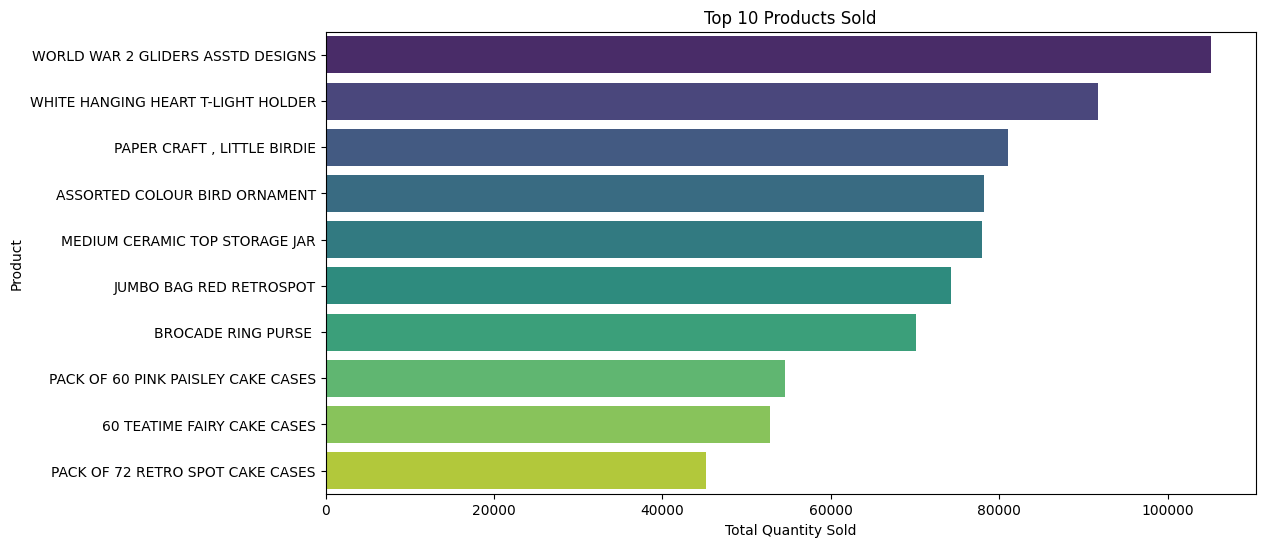

In [16]:
# Aggregate total quantity per product
product_totals = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)

# Take top 10 products
top_products = product_totals.head(10)

# Plot overall product distribution
plt.figure(figsize=(12,6))
sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.title("Top 10 Products Sold")
plt.show()

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


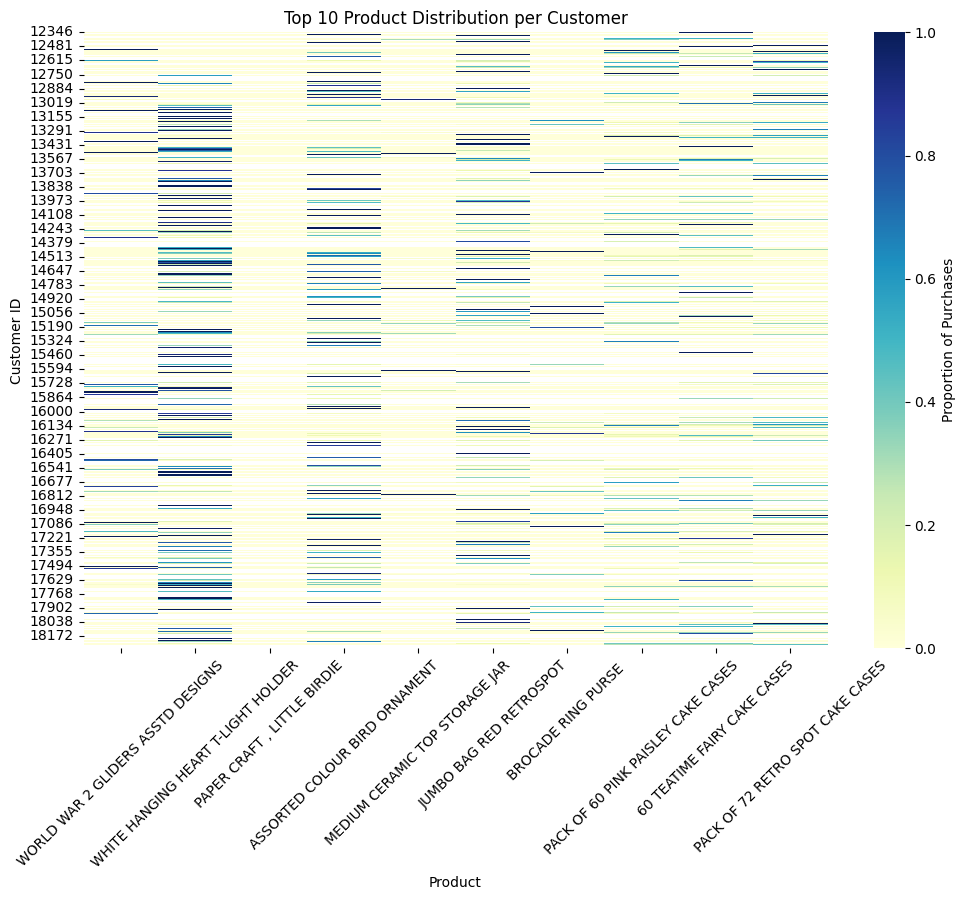

In [17]:
# Pivot table: rows=Customer, columns=Description, values=Quantity
product_dist = df.pivot_table(index='Customer ID', columns='Description', values='Quantity', aggfunc='sum', fill_value=0)

# Keep only top 10 products to avoid huge plot
product_dist_top = product_dist[top_products.index]

# Normalize per customer
product_dist_top_norm = product_dist_top.div(product_dist_top.sum(axis=1), axis=0)

# Visualize as heatmap (customers vs top products)
plt.figure(figsize=(12,8))
sns.heatmap(product_dist_top_norm, cmap="YlGnBu", cbar_kws={'label':'Proportion of Purchases'})
plt.xlabel("Product")
plt.xticks(rotation=45)
plt.ylabel("Customer ID")
plt.title("Top 10 Product Distribution per Customer")
plt.show()


<h1>Model Architecture and Result</h1>

The primary goal in this project is using unsupervised machine learning model to do customer segmentation. I tried 4 different model architectures.

<h2>Model 1: Product distribution + K-Means + PCA</h2>
Since we have a sense of the product that customers like to buy. 
We can cluster based on the Total quantity per product, the Proportion of each product purchased, the average price per product purchased.

First model we use is K-Means Clustering. K-Means is an unsupervised machine learning algorithm used to group data points into k distinct clusters based on similarity (Assign each data point to the nearest center point). It is one of the most widely used clustering methods in retail analytics, marketing, and customer segmentation because it is simple, fast, and interpretable.

In [18]:
# Full product distribution per customer
product_dist_full = df.pivot_table(
    index='Customer ID',
    columns='Description',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

# Normalize per customer to get distribution
product_dist_full_norm = product_dist_full.div(product_dist_full.sum(axis=1), axis=0)
product_dist_full_norm = product_dist_full_norm.fillna(0)

customer_features = pd.DataFrame(index=product_dist_full_norm.index)
customer_features['AvgQty'] = df.groupby('Customer ID')['Quantity'].mean()
customer_features['AvgPrice'] = df.groupby('Customer ID')['Price'].mean()
customer_features['UniqueProducts'] = df.groupby('Customer ID')['StockCode'].nunique()

X_product = pd.concat([product_dist_full_norm, customer_features], axis=1)
X_product = X_product.fillna(0)

print(X_product)

               DOORMAT UNION JACK GUNS AND ROSES   3 STRIPEY MICE FELTCRAFT  \
Customer ID                                                                   
12346                                        0.0                        0.0   
12347                                        0.0                        0.0   
12348                                        0.0                        0.0   
12349                                        0.0                        0.0   
12350                                        0.0                        0.0   
...                                          ...                        ...   
18283                                        0.0                        0.0   
18284                                        0.0                        0.0   
18285                                        0.0                        0.0   
18286                                        0.0                        0.0   
18287                                        0.0    

In [19]:
# Scale
scaler = StandardScaler()
X_scaled_product = scaler.fit_transform(X_product)

# PCA to reduce dimensions
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled_product)

print("Explained variance (100 components):", sum(pca.explained_variance_ratio_))


Explained variance (100 components): 0.08562322024097349


In [20]:
customer_features = pd.DataFrame(index=product_dist_full_norm.index)
customer_features['CustomerID'] = product_dist_full_norm.index  # keep as column
customer_features['AvgQty'] = df.groupby('Customer ID')['Quantity'].mean()
customer_features['AvgPrice'] = df.groupby('Customer ID')['Price'].mean()
customer_features['UniqueProducts'] = df.groupby('Customer ID')['StockCode'].nunique()

In [21]:
k = 5 # using 5 for testing
kmeans_product = KMeans(n_clusters=k, random_state=42)
clusters_product = kmeans_product.fit_predict(X_pca)

# Add cluster labels
customer_features['Cluster_Product'] = clusters_product

cluster_prod = customer_features.set_index('CustomerID')['Cluster_Product']

# Evaluate
score_product = silhouette_score(X_pca, clusters_product)
print(f"Silhouette Score for {k} clusters: {score_product:.3f}")


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Silhouette Score for 5 clusters: 0.942


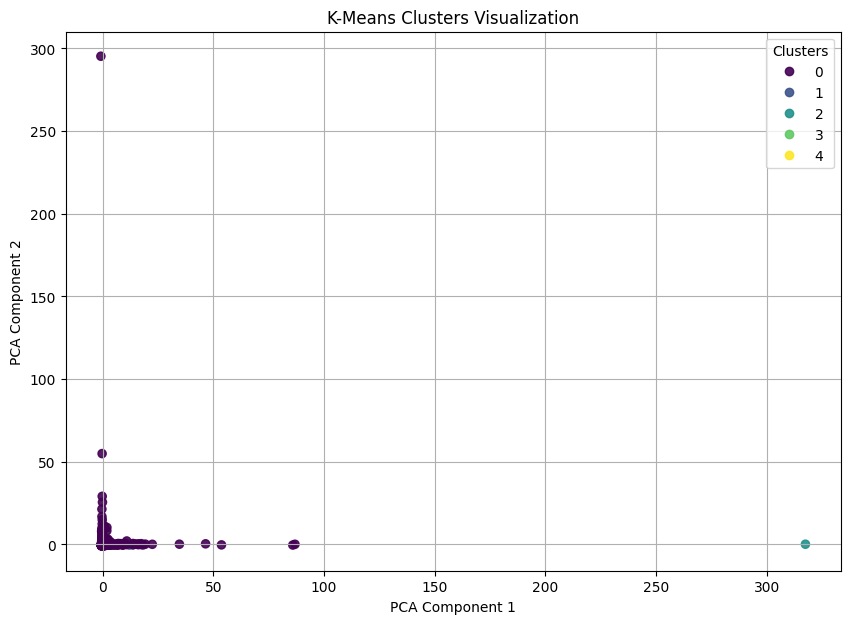

In [22]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_pca[:, 0], 
    X_pca[:, 1], 
    c=clusters_product, 
    s=35, 
    alpha=0.9
)

plt.title("K-Means Clusters Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.legend(*scatter.legend_elements(), title="Clusters")
plt.grid(True)
plt.show()

In [23]:
np.unique(clusters_product, return_counts=True)

(array([0, 1, 2, 3, 4], dtype=int32), array([5874,    1,    1,    1,    1]))

Conclusion: Model 1 failed to find meaningful clusters.

Silhouette Score but almost empty cluster.

Reason guess:
Most customers buy only a few products
PCA reduces info aggressively
K-Means finds one “big blob” + 4 tiny outliers

<h2>Model 2: RFM + K-Means</h2>

The second model in this project combines RFM with K-Means clustering to create meaningful customer segments based on purchasing behavior. RFM stands for Recency, Frequency, and Monetary value—three key dimensions that capture how recently a customer made a purchase, how often they purchase, and how much they spend overall. These features summarize each customer’s relationship with the retailer instead of looking at individual products.

In [24]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Reference date = max date in dataset
reference_date = df['InvoiceDate'].max()

# ---- RFM calculation ----
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,   # Recency
    'Invoice': 'nunique',                                      # Frequency
    'TotalAmount': 'sum'                                       # Monetary
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print(rfm.head())

   CustomerID  Recency  Frequency  Monetary
0       12346      325         12  77556.46
1       12347        1          8   4921.53
2       12348       74          5   2019.40
3       12349       18          4   4428.69
4       12350      309          1    334.40


In [25]:
X_rfm = rfm[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()
X_scaled_rfm = scaler.fit_transform(X_rfm)

In [26]:
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42)
    labels_rfm = km.fit_predict(X_scaled_rfm)
    score_rfm = silhouette_score(X_scaled_rfm, labels_rfm)
    print(f"k={k}, silhouette={score_rfm:.3f}")

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


k=2, silhouette=0.916


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


k=3, silhouette=0.583


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


...

k=5, silhouette=0.601


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


k=6, silhouette=0.550


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


k=7, silhouette=0.549


In [27]:
k = 2

kmeans_rfm = KMeans(n_clusters=k, random_state=42)
rfm['Cluster_RFM'] = kmeans_rfm.fit_predict(X_scaled_rfm)

cluster_summary = rfm.groupby('Cluster_RFM').mean().round(2)
print(cluster_summary)

             CustomerID  Recency  Frequency   Monetary
Cluster_RFM                                           
0              15314.62   201.00       5.78    2316.61
1              15500.77    22.09     143.05  173123.58


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


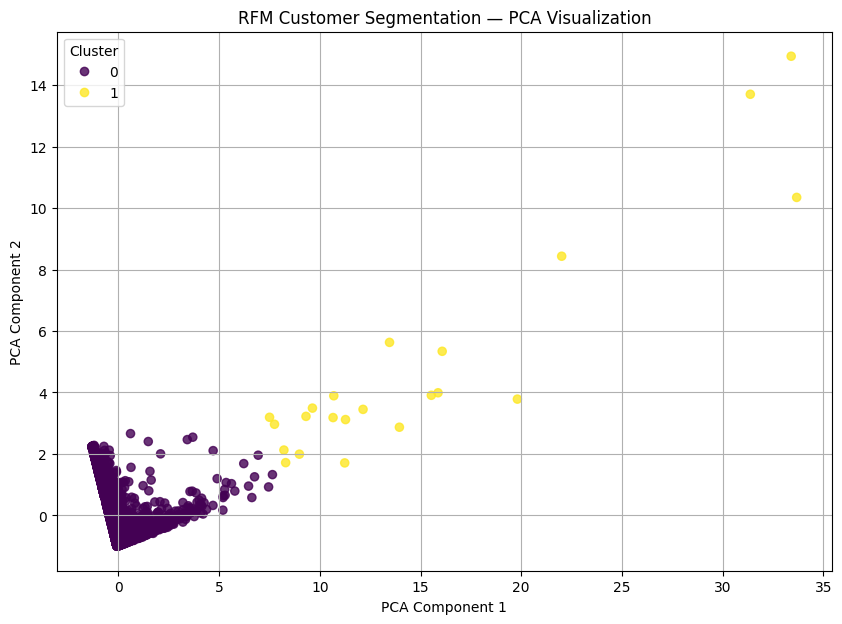

In [28]:
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(X_scaled_rfm)

plt.figure(figsize=(10,7))
scatter = plt.scatter(
    rfm_pca[:,0],
    rfm_pca[:,1],
    c=rfm['Cluster_RFM'],
    s=35,
    alpha=0.8
)

plt.title("RFM Customer Segmentation — PCA Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.grid(True)
plt.show()


The silhouette score is high when we do 2 clusters, but marketing strategry will do better if we can distinguish more type of users, in another word, more clusters.

In [29]:
k = 4
kmeans_k = KMeans(n_clusters=k, random_state=42)
rfm['Cluster_RMF_K'] = kmeans_k.fit_predict(X_scaled_rfm)

cluster_sizes = rfm['Cluster_RMF_K'].value_counts().sort_index()

score = silhouette_score(X_scaled_rfm, rfm['Cluster_RMF_K'])
print(f"k={k}, silhouette={score:.3f}")

print("Cluster sizes:")
print(cluster_sizes)

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


k=4, silhouette=0.590
Cluster sizes:
Cluster_RMF_K
0    3841
1    1998
2       4
3      35
Name: count, dtype: int64


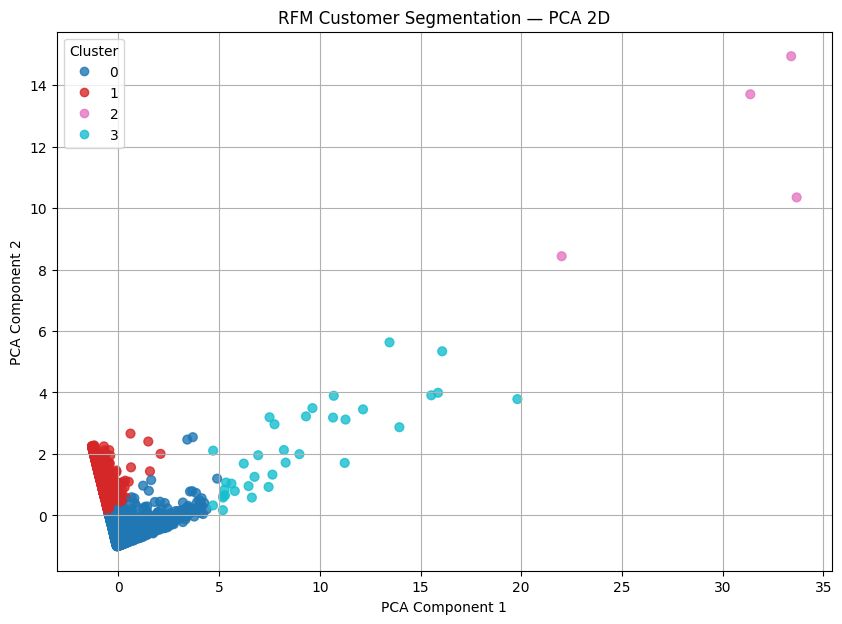

In [30]:
rfm_pca = pca.fit_transform(X_scaled_rfm)

plt.figure(figsize=(10,7))
scatter = plt.scatter(
    rfm_pca[:, 0],
    rfm_pca[:, 1],
    c=rfm['Cluster_RMF_K'],
    s=40,
    cmap='tab10',
    alpha=0.8
)

plt.title("RFM Customer Segmentation — PCA 2D")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.grid(True)
plt.show()


In [31]:
cluster_summary_k = rfm.groupby('Cluster_RMF_K')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print("Cluster summary (mean RFM_K values):")
print(cluster_summary_k)

Cluster summary (mean RFM_K values):
               Recency  Frequency   Monetary
Cluster_RMF_K                               
0                66.01       7.31    2946.45
1               462.03       2.21     748.54
2                 2.50     212.50  428612.00
3                24.94     103.71   81356.34


<h3>Interpret of Model 2 Results</h3>

Based on 4 clusters' results. We can distinguish the customers into different groups.

Cluster O: Moderate-Value, Steady Customers. (Recency = 66 days, Frequency = 7.3, Monetary = 2.9k) This group represents typical shoppers who buy occasionally and spend a moderate amount. 

Cluster 1: Low-Value or At-Risk Customers. (Recency = 462 days, Frequency = 2.2, Monetary = 748) These customers have not purchased for a long time, buy infrequently, and spend very little. They are the most at-risk group and may be close to churning or no longer active.

Cluster 2: Ultra-High-Value, Extremely Active Customers.(Recency = 2.5 days, Frequency = 212.5, Monetary = 428k+) This group represents a very small but extremely important customer segment.They purchase remarkably frequently, spend far more than any other segment, and return very recently, making them the company’s highest-value and most engaged customers.

Cluster 3: High-Value and Loyal Customers. (Recency = 25 days, Frequency = 103.7, Monetary = 81k+) This group consists of consistently active, high-spending customers.
Their purchase frequency is high, and they spend considerably more than the average customer. They are not as extreme as Cluster 2 but remain core to the business.

<h2>Model 3: RFM + GMM</h2>
For model 3, I want to try RFM + Gaussian Mixture Model (GMM).
Compared with K-Means, GMM allows soft clustering, so customers can belong to multiple segments with different probabilities. It may often be more realistic than K-Means for customer segmentation.

In [32]:
X_gmm = rfm[['Recency', 'Frequency', 'Monetary']]
scaler = StandardScaler()
X_scaled_gmm = scaler.fit_transform(X_gmm)

In [33]:
from sklearn.mixture import GaussianMixture

k = 4
gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
gmm_labels = gmm.fit_predict(X_scaled_gmm)

# Add cluster labels to RFM dataframe
rfm['Cluster_GMM'] = gmm_labels

# Get probabilities for soft assignments
rfm[['Prob_Cluster_'+str(i) for i in range(k)]] = gmm.predict_proba(X_scaled_gmm)

In [34]:
cluster_sizes_gmm = rfm['Cluster_GMM'].value_counts().sort_index()
print("Cluster sizes:")
print(cluster_sizes_gmm)

Cluster sizes:
Cluster_GMM
0    1648
1    3775
2       4
3     451
Name: count, dtype: int64


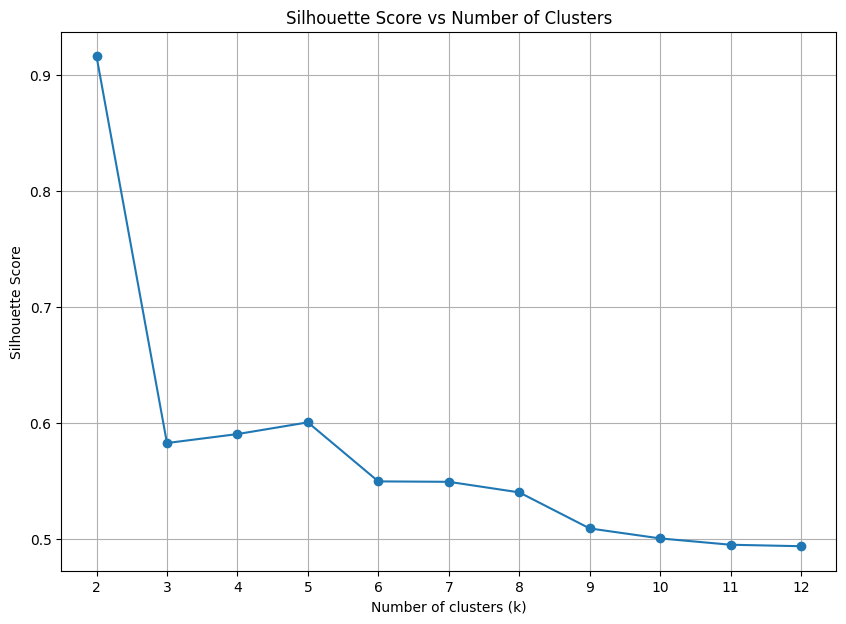

In [35]:
# Compute inertia and silhouette for a range of K
sil_scores = []
K_range = range(2, 13)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled_gmm)
    sil_scores.append(silhouette_score(X_scaled_gmm, labels))

# Plot silhouette score
plt.figure(figsize=(10,7))
plt.plot(K_range, sil_scores, marker='o', linestyle='-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [36]:
k_gmm = 4
km_gmm = KMeans(n_clusters=k_gmm, random_state=42, n_init=10)
label_gmm = km_gmm.fit_predict(X_scaled_gmm)

score_gmm = silhouette_score(X_scaled_gmm, label_gmm)
print(f"k={k_gmm}, silhouette={score_gmm:.3f}")

k=4, silhouette=0.590


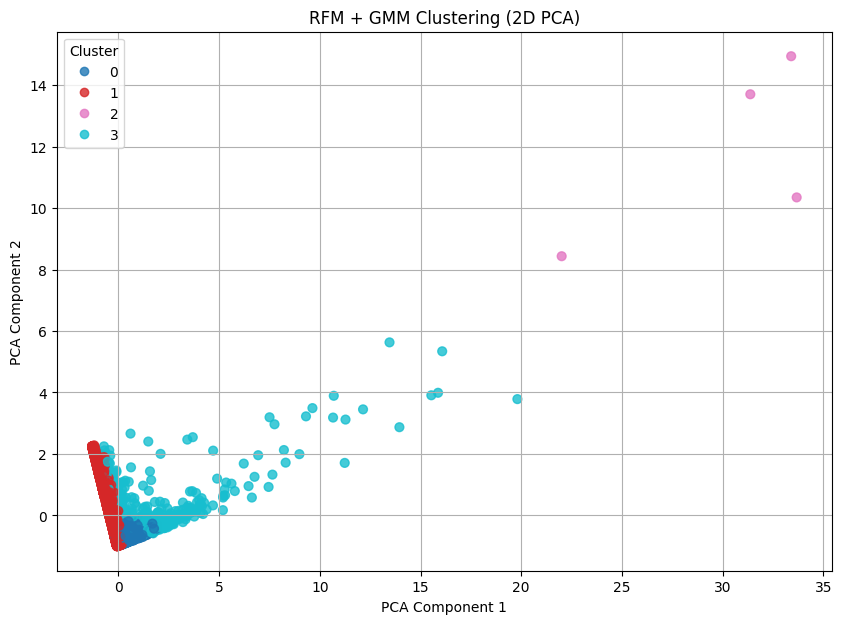

In [37]:
pca_gmm = PCA(n_components=2)
rfm_gmm = pca_gmm.fit_transform(X_scaled_gmm)

plt.figure(figsize=(10,7))
scatter = plt.scatter(
    rfm_gmm[:, 0],
    rfm_gmm[:, 1],
    c=gmm_labels,
    cmap='tab10',
    s=40,
    alpha=0.8
)
plt.title("RFM + GMM Clustering (2D PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.grid(True)
plt.show()

In [38]:
cluster_summary_gmm = rfm.groupby('Cluster_GMM')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print("Cluster summary:")
print(cluster_summary_gmm)

Cluster summary:
             Recency  Frequency   Monetary
Cluster_GMM                               
0              37.11       9.73    3499.77
1             276.40       2.26     596.13
2               2.50     212.50  428612.00
3             161.83      25.62   16945.35


<h3>Model 3 Interpret Results</h3>

Cluster 0: Regular customers with moderate value. (Recency = 37 days, Frequency = 9.73, Monetary = 3.5k) Not the highest spenders, but somewhat loyal and engaged.

Cluster 1:Low-Value or At-Risk Customers.(Recency = 276 days, Frequency = 2.26, Monetary = 596) These customers have not purchased for a long time, buy infrequently, and spend very little. They are the most at-risk group and may be close to churning or no longer active.

Cluster 2: Ultra-High-Value, Extremely Active Customers.(Recency = 2.5 days, Frequency = 212, Monetary = 428k+) This group represents a very small but extremely important customer segment.They purchase remarkably frequently, spend far more than any other segment, and return very recently, making them the company’s highest-value and most engaged customers.

Cluster 3: High-Value and Loyal Customers. (Recency = 161 days, Frequency = 25.62, Monetary = 16K) This group consists of consistently active, high-spending customers. Their purchase frequency is high, and they spend considerably more than the average customer. They are not as extreme as Cluster 2 but remain core to the business.


<h2>Model 4: Jaccard based customer segmentation</h2>

Collaborative segmentation treats customers as “similar” if they purchase similar products, instead of relying on pre-defined features like RFM. We compute the Jaccard similarity between each pair of customers.Then applying agglomerative hierarchical clustering to group customers with similar purchase patterns into clusters.

In [39]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances

# Prepare customer-product binary matrix
customer_product = df.pivot_table(
    index='Customer ID',
    columns='StockCode',
    values='Quantity',
    aggfunc=lambda x: 1 if x.sum() > 0 else 0,
    fill_value=0
)
customer_product = customer_product.astype(int)

# reduce product dimension if too large
# top_products = customer_product.sum().sort_values(ascending=False).head(200).index
# customer_product = customer_product[top_products]

# Compute Jaccard distance matrix once
jaccard_dist = pairwise_distances(customer_product.values, metric='jaccard')

# Loop over cluster numbers
cluster_range = range(2, 11)  # test k=2 to 10
cluster_results = {}
sil_scores = {}

for k in cluster_range:
    agg = AgglomerativeClustering(
        n_clusters=k,
        affinity='precomputed',  # using distance matrix
        linkage='average'
    )
    labels = agg.fit_predict(jaccard_dist)
    cluster_results[k] = labels + 1  # optional: make clusters start from 1
    
    # Silhouette score
    sil = silhouette_score(jaccard_dist, labels, metric='precomputed')
    sil_scores[k] = sil
    
    # Cluster sizes
    unique, counts = np.unique(labels, return_counts=True)
    print(f"k={k}, cluster sizes: {dict(zip(unique+1, counts))}, silhouette={sil:.3f}")

#choose best k
best_k = max(sil_scores, key=sil_scores.get)
print("Best k based on silhouette:", best_k)
rfm['Cluster_Jaccard'] = cluster_results[best_k]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/pairwise.py:2025: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


k=2, cluster sizes: {1: 5877, 2: 1}, silhouette=0.016


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


k=3, cluster sizes: {1: 5876, 2: 1, 3: 1}, silhouette=0.016


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


...

k=8, cluster sizes: {1: 5871, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1, 8: 1}, silhouette=0.016


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


k=9, cluster sizes: {1: 5870, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1, 8: 1, 9: 1}, silhouette=0.016


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_agglomerative.py:983: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


k=10, cluster sizes: {1: 5869, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1, 8: 1, 9: 1, 10: 1}, silhouette=0.015
Best k based on silhouette: 2


In [40]:
chosen_k = 8
rfm['Cluster_Jaccard'] = cluster_results[chosen_k]
print(rfm['Cluster_Jaccard'].value_counts())

Cluster_Jaccard
1    5871
8       1
5       1
7       1
4       1
6       1
3       1
2       1
Name: count, dtype: int64


In [41]:
label_jaccard = rfm['Cluster_Jaccard']
sil_jaccard = silhouette_score(jaccard_dist, label_jaccard, metric='precomputed')
print("Silhouette Jaccard:", sil_jaccard)

Silhouette Jaccard: 0.015723669558304933


Most customers buy only a small subset of all products.

Jaccard similarity is 0 for nearly every pair, because the intersection of purchased products is empty.It forces almost everyone into one big cluster.

<h1>Recommandation Result and Analysis</h1>

After segmenting customers,we generated product recommendations tailored to each cluster for model 2 and model 3. Since these 2 models successfully captured customers' differences.

In [42]:
def get_top_products_per_cluster(df, cluster_series, top_n=5):
    df = df.copy()
    df['Cluster'] = df['Customer ID'].map(cluster_series)
    top_products = {}

    for cl in cluster_series.unique():
        subset = df[df['Cluster'] == cl]
        top_items = (
            subset.groupby('StockCode')['Quantity']
            .sum()
            .sort_values(ascending=False)
            .head(top_n)
            .index.tolist()
        )
        top_products[cl] = top_items

    return top_products

In [43]:
def assign_recommendations(cluster_series, top_products_dict):
    recommendations = {}
    for cid, clus in cluster_series.items():
        recommendations[cid] = top_products_dict[clus]
    return recommendations

def map_stockcode_to_desc(df, recommendations_dict):
    # Create mapping
    code2desc = df.set_index('StockCode')['Description'].to_dict()
    # Map codes to descriptions
    mapped = {}
    for cid, codes in recommendations_dict.items():
        mapped[cid] = [code2desc.get(code, code) for code in codes]
    return mapped

df['Customer ID'] = df['Customer ID'].astype(str)

<h2>Recommendation using Model 2: RFM + K-Means</h2>

Recommendation Strategy: For each cluster, the most popular products purchased by other customers in the same cluster were recommended.

In [44]:
# Example: RFM KMeans
rfm['CustomerID'] = rfm['CustomerID'].astype(str)
cluster_rfm = rfm.set_index('CustomerID')['Cluster_RFM']
cluster_rfm.index = cluster_rfm.index.astype(str)

top_rfm = get_top_products_per_cluster(df, cluster_rfm, top_n=5)
rec_rfm = assign_recommendations(cluster_rfm, top_rfm)
rec_rfm_desc = map_stockcode_to_desc(df, rec_rfm)

print("Sample Customer Recommendations (RFM + KMeans):")
for cid, prods in list(rec_rfm_desc.items())[:5]:
    print(f"Customer {cid}: {prods}")

Sample Customer Recommendations (RFM + KMeans):
Customer 12346: ['WORLD WAR 2 GLIDERS ASSTD DESIGNS', 'MEDIUM CERAMIC TOP STORAGE JAR', 'CREAM HANGING HEART T-LIGHT HOLDER', 'JUMBO BAG RED RETROSPOT', 'ASSORTED COLOUR BIRD ORNAMENT']
Customer 12347: ['WORLD WAR 2 GLIDERS ASSTD DESIGNS', 'MEDIUM CERAMIC TOP STORAGE JAR', 'CREAM HANGING HEART T-LIGHT HOLDER', 'JUMBO BAG RED RETROSPOT', 'ASSORTED COLOUR BIRD ORNAMENT']
Customer 12348: ['WORLD WAR 2 GLIDERS ASSTD DESIGNS', 'MEDIUM CERAMIC TOP STORAGE JAR', 'CREAM HANGING HEART T-LIGHT HOLDER', 'JUMBO BAG RED RETROSPOT', 'ASSORTED COLOUR BIRD ORNAMENT']
Customer 12349: ['WORLD WAR 2 GLIDERS ASSTD DESIGNS', 'MEDIUM CERAMIC TOP STORAGE JAR', 'CREAM HANGING HEART T-LIGHT HOLDER', 'JUMBO BAG RED RETROSPOT', 'ASSORTED COLOUR BIRD ORNAMENT']
Customer 12350: ['WORLD WAR 2 GLIDERS ASSTD DESIGNS', 'MEDIUM CERAMIC TOP STORAGE JAR', 'CREAM HANGING HEART T-LIGHT HOLDER', 'JUMBO BAG RED RETROSPOT', 'ASSORTED COLOUR BIRD ORNAMENT']


<h2>Recommendation using Model 3: RFM + GMM</h2>

The soft clustering of GMM allows more personalized recommendations by considering nuanced customer behaviors, producing slightly different top products for each individual, even within the same cluster.

In [45]:
# Example: GMM KMeans
rfm['CustomerID'] = rfm['CustomerID'].astype(str)
cluster_rfm = rfm.set_index('CustomerID')['Cluster_GMM']
cluster_rfm.index = cluster_rfm.index.astype(str)

top_rfm = get_top_products_per_cluster(df, cluster_rfm, top_n=5)
rec_rfm = assign_recommendations(cluster_rfm, top_rfm)
rec_rfm_desc = map_stockcode_to_desc(df, rec_rfm)

print("Sample Customer Recommendations (RFM + GMM):")
for cid, prods in list(rec_rfm_desc.items())[:5]:
    print(f"Customer {cid}: {prods}")

Sample Customer Recommendations (RFM + GMM):
Customer 12346: ['PAPER CRAFT , LITTLE BIRDIE', 'MEDIUM CERAMIC TOP STORAGE JAR', 'WORLD WAR 2 GLIDERS ASSTD DESIGNS', 'JUMBO BAG RED RETROSPOT', 'POPCORN HOLDER']
Customer 12347: ['WORLD WAR 2 GLIDERS ASSTD DESIGNS', 'SMALL CHINESE STYLE SCISSOR', 'CREAM HANGING HEART T-LIGHT HOLDER', 'ASSORTED COLOUR BIRD ORNAMENT', 'JUMBO BAG RED RETROSPOT']
Customer 12348: ['WORLD WAR 2 GLIDERS ASSTD DESIGNS', 'SMALL CHINESE STYLE SCISSOR', 'CREAM HANGING HEART T-LIGHT HOLDER', 'ASSORTED COLOUR BIRD ORNAMENT', 'JUMBO BAG RED RETROSPOT']
Customer 12349: ['WORLD WAR 2 GLIDERS ASSTD DESIGNS', 'SMALL CHINESE STYLE SCISSOR', 'CREAM HANGING HEART T-LIGHT HOLDER', 'ASSORTED COLOUR BIRD ORNAMENT', 'JUMBO BAG RED RETROSPOT']
Customer 12350: ['CREAM HANGING HEART T-LIGHT HOLDER', 'WORLD WAR 2 GLIDERS ASSTD DESIGNS', 'PACK OF 72 RETROSPOT CAKE CASES', 'ASSORTED COLOURS SILK FAN', 'ASSORTED COLOUR BIRD ORNAMENT']


<h1>Conclusion</h1>

To simulate the experience of how modern e-commerce companies build their recommendation pipelines, I began this project by focusing on customer segmentation using unsupervised machine learning techniques.

The analysis was performed using four different segmentation models—each designed to capture different aspects of customer behavior:

Product Distribution + PCA + K-Means (Model 1)

RFM Features + K-Means (Model 2)

RFM Features + Gaussian Mixture Model (GMM) (Model 3)

Jaccard + Hierarchical Clustering (Model 4)

<h2>Evaluation - Problems I Meet</h2>

Initially, silhouette score was used to determine cluster quality. However, it consistently favored 2 clusters for all models.
Although mathematically valid, this produced very unbalanced clusters, where almost all customers fell into one cluster, and only a small number formed the second cluster.

Therefore, I evaluated models using more actionable criteria, including distribution balance across clusters, business interpretability. This approach resulted in much more valuable segmentation outcomes.

Among the 4 models. Model 2 is best for segmentation and model 3 is best for personalization.

Their clustering results have some similar parts. By analysis, the main difference is that Model 3 has a wider range for the second-level high-value and loyal customers.
From a cluster balance and personalization perspective, Model 3 has a better result. However, Model 2 may be easier to interpret. It will be better to compare model output with user research questionnaire to get better ideas.

<h2>Future Work</h2>

In the future, I may continue looking for better model evaluation methods. And try more clustering methods, including sequential modeling to find users' behaviour change.


<h1>Reference</h1>

RFM: https://www.investopedia.com/terms/r/rfm-recency-frequency-monetary-value.asp

<h1>Github</h1>
https://github.com/meng-shi/Customer-Segmentation
